# Snakes and Ladders
[Leetcode Link](https://leetcode.com/problems/snakes-and-ladders/description/)
You are given an n x n integer matrix board where the cells are labeled from 1 to n2 in a Boustrophedon style starting from the bottom left of the board (i.e. board[n - 1][0]) and alternating direction each row.

You start on square 1 of the board. In each move, starting from square curr, do the following:

Choose a destination square next with a label in the $range(curr + 1, min(curr + 6, n^2))$.
This choice simulates the result of a standard 6-sided die roll: i.e., there are always at most 6 destinations, regardless of the size of the board.
If next has a snake or ladder, you must move to the destination of that snake or ladder. Otherwise, you move to next.
The game ends when you reach the square n2.
A board square on row r and column c has a snake or ladder if board[r][c] != -1. The destination of that snake or ladder is board[r][c]. Squares 1 and n2 are not the starting points of any snake or ladder.

Note that you only take a snake or ladder at most once per dice roll. If the destination to a snake or ladder is the start of another snake or ladder, you do not follow the subsequent snake or ladder.

For example, suppose the board is [[-1,4],[-1,3]], and on the first move, your destination square is 2. You follow the ladder to square 3, but do not follow the subsequent ladder to 4.
Return the least number of dice rolls required to reach the square n2. If it is not possible to reach the square, return -1.

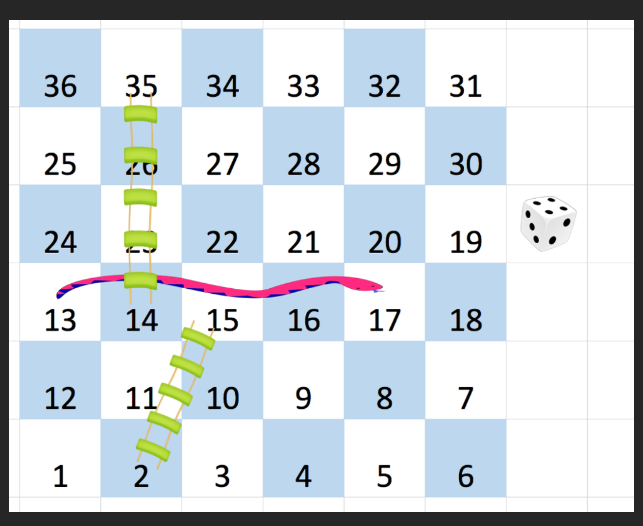

### Constraints
* n == board.length == board[i].length
* 2 <= n <= 20
* board[i][j] is either -1 or in the range [1, n2].
* The squares labeled 1 and n2 are not the starting points of any snake or ladder.

## Approach #1: BFS with board index conversion

In order to lookup whether a snake or ladder exists at a square, we need to know its index in board. We can create a function specifically to make this conversion. The row and column indexes are related to the ceiling of `square_number/n`, and we'd have to derive mathematical formulas based on that.

Then, we do a breadth-first search starting at square 1, until we reach square $n^2$. Our `seen` set stores squares we've already visited. For each square, we iterate over 6 moves (corresponding to all the possible moves with each dice roll).

 For each move, we need to check `seen` to ensure we haven't made the move yet. Then, we add that move to `seen` before proceeding. It's very important to add the move to `seen` immediately after checking for it. This avoids adding duplicates and hitting memory limits.
 Then, we convert the square to the board index, and lookup in the board whether it's a snake/ladder. If it is a snake/ladder, we add the value that it jumps to in our queue `destinations` instead of the next move. Otherwise we add the next move to `destination`. Each item in `destinations` also has the `steps` we counted so far. When we pop that square out of `destination`, we check whether it is $n^2$ in which case, we return the associated `steps`.  

### Analysis
* Time complexity: $O(N^2)$
    * we may have to iterate over all the squares before reaching our solution
    * optimal
* Space Complexity: $O(N^2)$
    * space required for `seen` set, in the case if we do iterate over all the squares
* Code Complexity: 9 Cyclomatic Complexity 
    * The board index conversion function is not ideal. It's difficult and nonintuitive to derive the formulas, so it's very prone to mistakes during code interviews. It's also hard to debug if there is a bug in the function 

In [ ]:
from collections import deque
from math import ceil
from typing import List

def snakesAndLadders(board: List[List[int]]) -> int:
    n = len(board)

    def get_board_pos(square_number):
        nonlocal n
        if square_number < 1 or square_number > n*n:
            return None
        row_number = n - ceil(square_number/n)
        go_left = (n-row_number)%2
        col_number = (ceil(square_number/n) * n) - square_number

        if go_left:
            col_number = (n-1) - col_number
        return (row_number,col_number)

    destinations = deque([(1,0)])
    seen = {1}

    while destinations:
        curr, steps = destinations.popleft()
        if curr == n*n:
            return steps
        for go in range(1,7):
            next_num = curr + go
            next_steps = steps + 1
            if next_num in seen:
                continue
            seen.add(next_num)
            next_board = get_board_pos(next_num)
            if next_board != None: 
                if board[next_board[0]][next_board[1]] != -1:
                    next_num = board[next_board[0]][next_board[1]]
                destinations.append((next_num, next_steps))
    return -1


## Approach #2: Convert to 1D Array then BFS
Instead of trying to lookup values directly in `board`, we can simply convert `board` to a 1D array `squares`. This allows us to lookup values with simple indexes. The conversion can be done with a double nested loop. We still need to account for rows where squares are in reverse order, but we can easily determine whether a `row` reads left-to-right with the formula `left_right = (n-row)%2`.

From there, we just need to make simple modifications to the BFS to use the new `squares` array.

### Analysis
* Time complexity: $O(N^2)$
    * we may have to iterate over all the squares before reaching our solution
    * optimal
* Space Complexity: $O(N^2)$
    * space required for `squares` array and `seen` set
* Code Complexity: 8 Cyclomatic Complexity 
    * probably the best we can do
    * we also reduced the complexity by 1 when we modfied the for loop to only iterate over `range(curr+1, min(curr+6, n**2) + 1)`, eliminating the need to check if `next_num` is within the range of the board


In [ ]:
from collections import deque
from math import ceil

def snakesAndLadders(board: List[List[int]]) -> int:
    n = len(board)
    squares = []

    for i in range(n-1,-1,-1):
        left_right = (n-i)%2
        col_order = range(n) if left_right else range(n-1,-1,-1)
        for j in col_order:
            squares.append(board[i][j])

    destinations = deque([(1,0)])
    seen = {1}
   
        
    while destinations:
        curr, steps = destinations.popleft()
        if curr == n*n:
            return steps
        for next_num in range(curr+1, min(curr+6, n**2) + 1):
            next_steps = steps + 1
            next_square = squares[next_num-1]
            if next_square != -1:
                next_num = next_square
            if next_num in seen:
                continue
            seen.add(next_num)
            destinations.append((next_num, next_steps))
    return -1